# SC2Artic-Q11

Analyzes SARS-CoV-2 sequence data from Q11 sequencing run (Illumina MiSeq 500 cycle nano kit).


## Setup and Alignment Commands
Define the file paths and perform alignment using BWA to the SARS-CoV-2 reference genome.

In [1]:
import os
import subprocess
import glob
import pandas as pd
import re
from IPython.display import display

# Safely identify the original notebook project root even if the kernel has already been subjected to %cd shifts
if 'notebook_dir' not in globals() or not notebook_dir.endswith('RespiCov-analyze'):
    # Search backwards until we hit the correct project root
    current = os.path.abspath(os.curdir)
    while current and not current.endswith('RespiCov-analyze') and current != '/':
        current = os.path.dirname(current)
    notebook_dir = current if current.endswith('RespiCov-analyze') else os.path.abspath(os.curdir)
    
    work_dir = os.path.join(notebook_dir, "../Q11-MG1-SC2")
    out_dir = os.path.join(work_dir, "alignments")
    import shutil
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)
    get_ipython().run_line_magic("cd", out_dir)

# Define pipeline execution variables relative to the securely locked origin path
fastq_dir = os.path.join(work_dir, "JobID-872")
reference = os.path.abspath(os.path.join(notebook_dir, "../primer_schemes/SARS-CoV-2.reference.fasta"))
scheme = os.path.abspath(os.path.join(notebook_dir, "../primer_schemes/ARTIC-V5.4.2.scheme.bed"))
q10_out_dir = os.path.join(work_dir, "alignments_q10")

samples = ["RB1-S116", "RB2-S151", "RB3-S171"]

if not os.path.exists(reference + ".bwt"):
    print("Indexing reference genome...")
    subprocess.run(["bwa", "index", reference], check=True)
else:
    print("Reference genome already indexed.")

def align_and_trim(sample, target_out_dir=out_dir):
    print(f"Processing {sample}...")
    import subprocess
    import os
    import glob
    
    r1_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R1_001.fastq.gz"))
    r2_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R2_001.fastq.gz"))
    
    if not r1_files or not r2_files:
        print(f"FASTQ files not found for {sample}")
        return None
        
    r1 = r1_files[0]
    r2 = r2_files[0]
    
    bam_out = os.path.join(target_out_dir, f"{sample}.bam")
    final_bam = os.path.join(target_out_dir, f"{sample}.trimmed.sorted.bam")
    
    try:
        # Align raw reads and sort
        bwa_cmd = f"bwa mem -t 4 {reference} {r1} {r2} | samtools sort -o {bam_out}"
        subprocess.run(bwa_cmd, shell=True, check=True)
        
        # Soft-clip primers and sort
        clip_cmd = f"samtools ampliconclip -b {scheme} {bam_out} | samtools sort -o {final_bam}"
        subprocess.run(clip_cmd, shell=True, check=True)
        
        # Index the final sorted clipped BAM
        subprocess.run(["samtools", "index", final_bam], check=True)
        
        print(f"Finished {sample}.")
        return final_bam
        
    except subprocess.CalledProcessError as e:
        print(f"Alignment pipeline failed for {sample}: {e}")
        return None


/Users/rick/Lab/Q11-MG1-SC2/alignments
Reference genome already indexed.


## Base Quality Distribution
Visualize the Phred base quality scores of the input reads using Biopython. In Illumina sequencing we expect quality to start high and drop off as the read progresses, and also R2 to have somewhat lower quality than R1 (since it occurs afterwards).

Processing fastq qualities for RB1-S116...


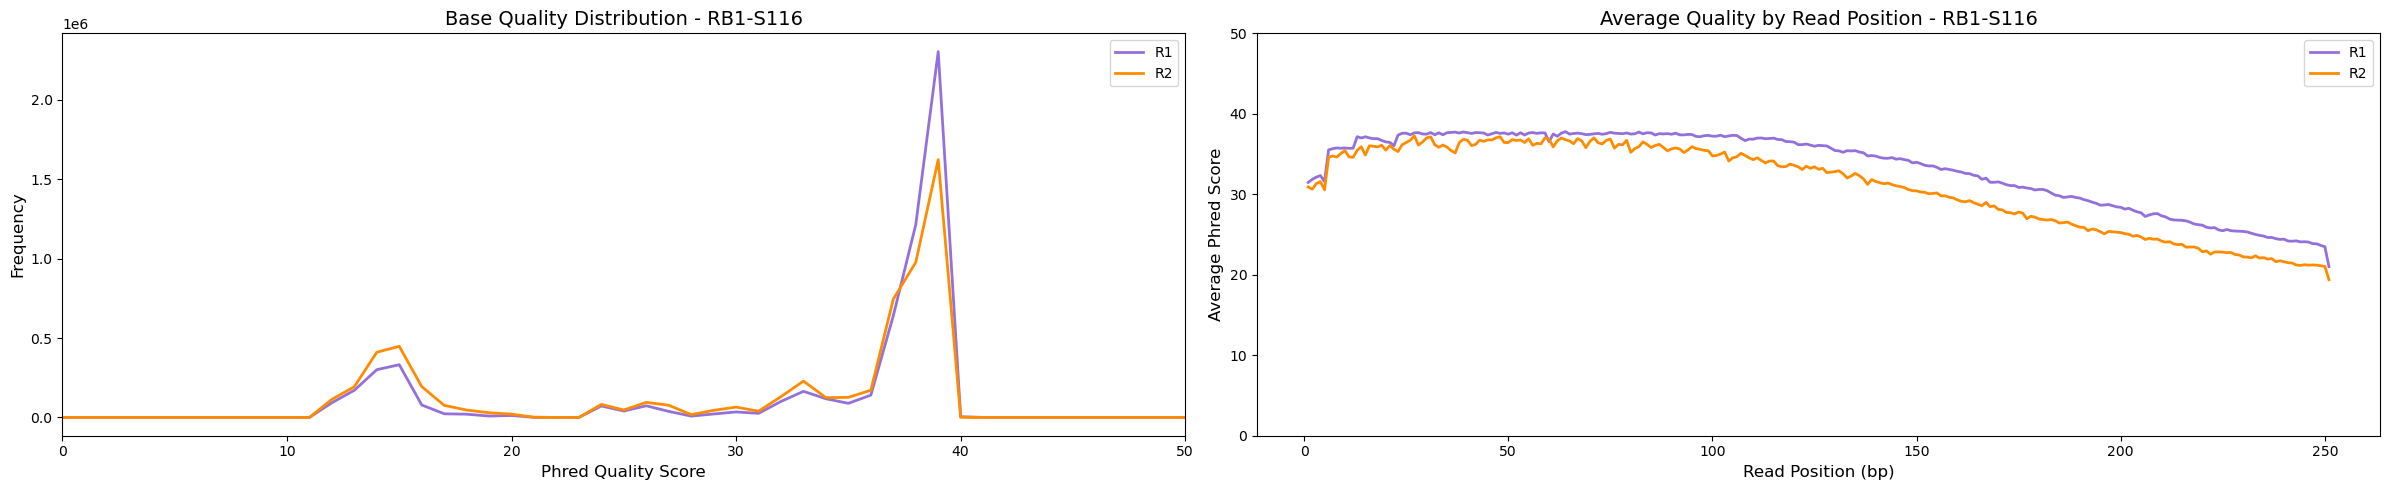

Processing fastq qualities for RB2-S151...


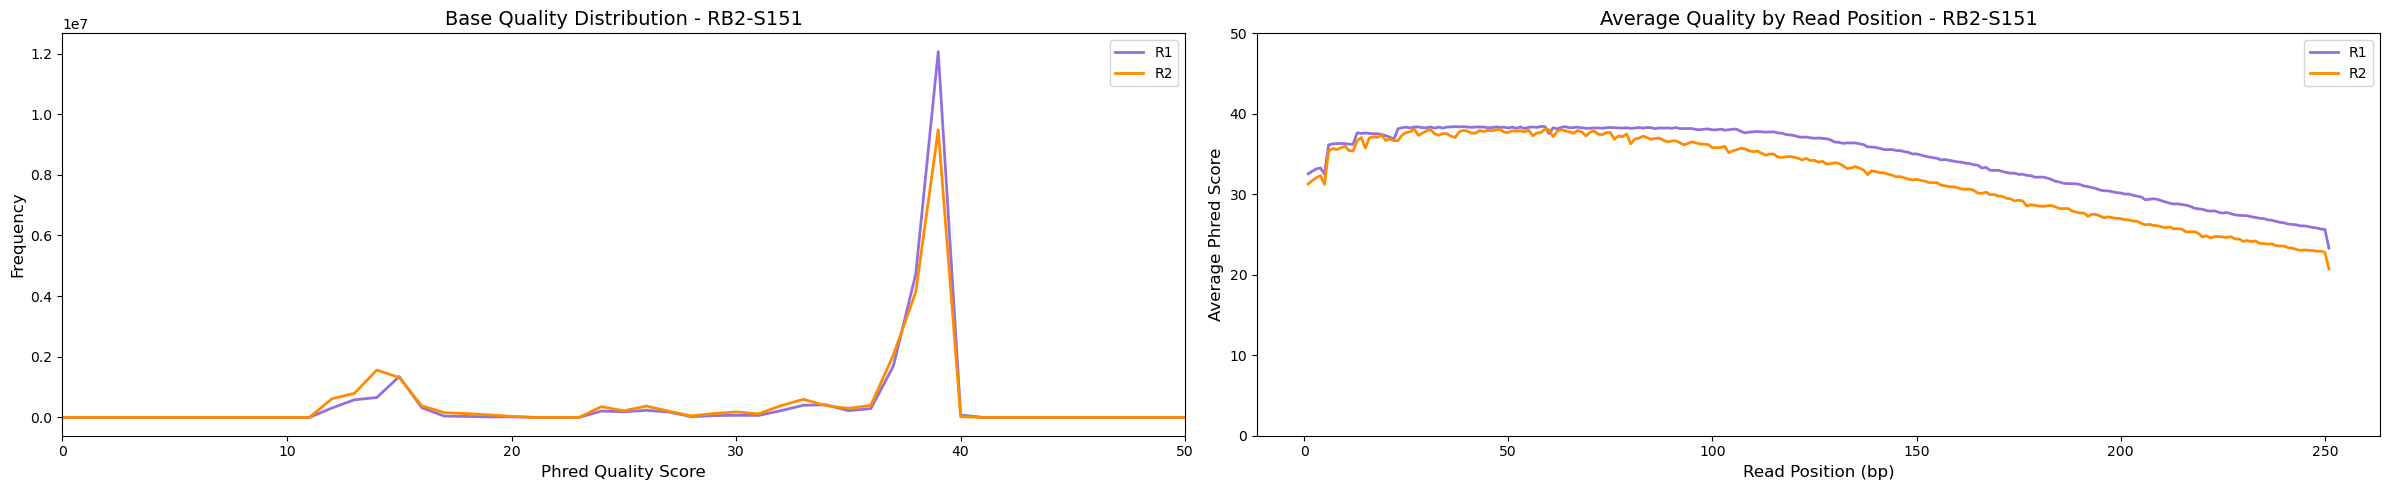

Processing fastq qualities for RB3-S171...


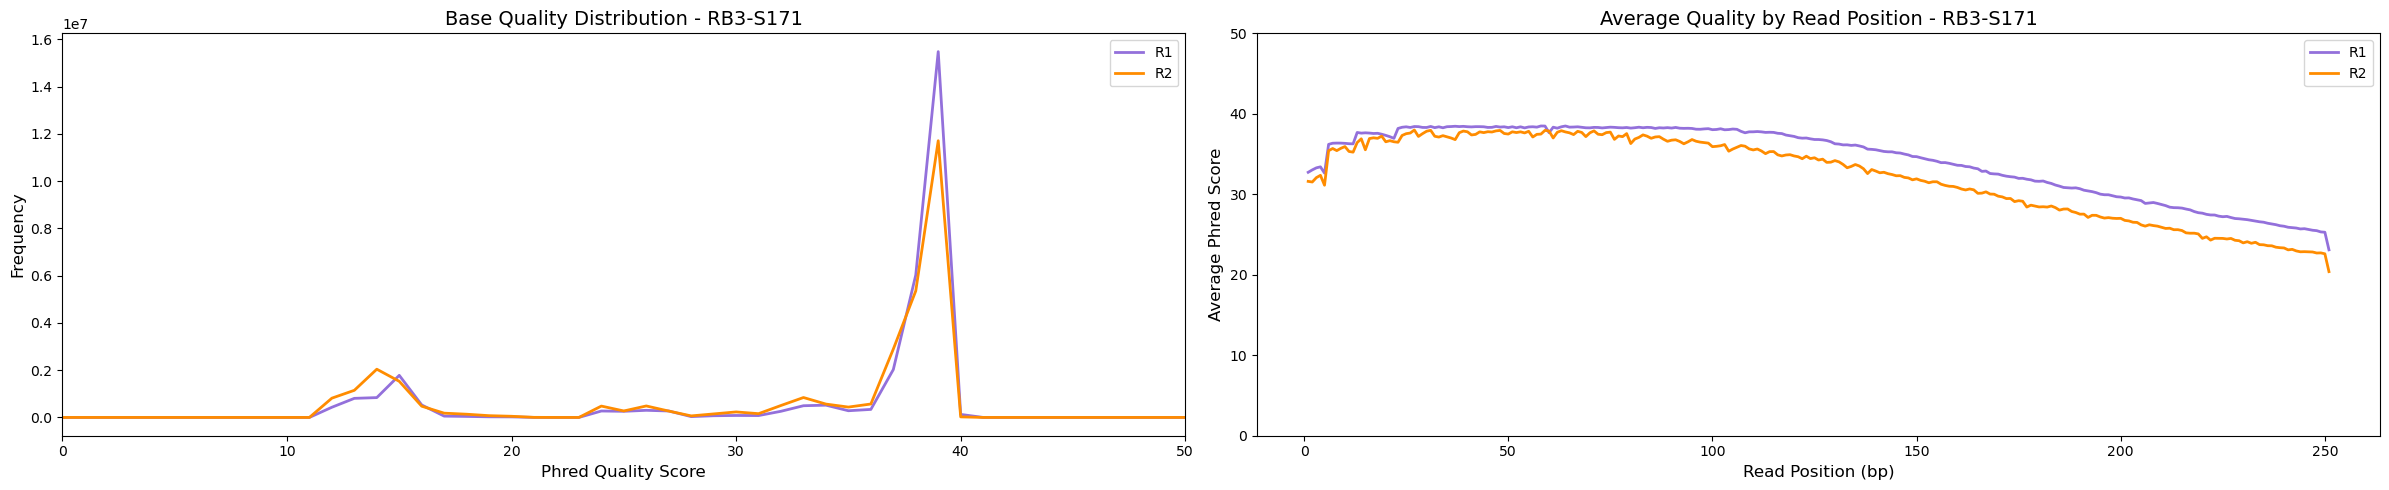

In [2]:
import gzip
import glob
import matplotlib.pyplot as plt
from Bio import SeqIO
from collections import Counter

for sample in samples:
    r1_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R1_001.fastq.gz"))
    r2_files = glob.glob(os.path.join(fastq_dir, f"{sample}_*_R2_001.fastq.gz"))
    
    if not r1_files or not r2_files: 
        continue
        
    def get_qualities(fastq_file):
        dist_counts = Counter()
        pos_sums = []
        pos_counts = []
        pos_q20_counts = []
        
        with gzip.open(fastq_file, "rt") as handle:
            for record in SeqIO.parse(handle, "fastq"):
                quals = record.letter_annotations["phred_quality"]
                
                # 1. Total Distribution Tracking
                dist_counts.update(quals)
                
                # 2. Positional Tracking
                while len(pos_sums) < len(quals):
                    pos_sums.append(0)
                    pos_counts.append(0)
                    pos_q20_counts.append(0)
                for i, q in enumerate(quals):
                    pos_sums[i] += q
                    pos_counts[i] += 1
                    if q >= 20:
                        pos_q20_counts[i] += 1
                    
        avg_quals = [s/c if c > 0 else 0 for s, c in zip(pos_sums, pos_counts)]
        frac_q20 = [q/c if c > 0 else 0 for q, c in zip(pos_q20_counts, pos_counts)]
        return dist_counts, avg_quals, frac_q20

    print(f"Processing fastq qualities for {sample}...")
    r1_dist, r1_pos, r1_q20 = get_qualities(r1_files[0])
    r2_dist, r2_pos, r2_q20 = get_qualities(r2_files[0])
    
    scores = list(range(51))
    r1_freqs = [r1_dist.get(s, 0) for s in scores]
    r2_freqs = [r2_dist.get(s, 0) for s in scores]
            
    if sum(r1_freqs) > 0 or sum(r2_freqs) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 5))
        
        # Plot 1: Overall Quality Distribution
        ax1.plot(scores, r1_freqs, label='R1', color='mediumpurple', linewidth=2)
        ax1.plot(scores, r2_freqs, label='R2', color='darkorange', linewidth=2)
        ax1.set_title(f"Base Quality Distribution - {sample}", fontsize=14)
        ax1.set_xlabel("Phred Quality Score", fontsize=12)
        ax1.set_ylabel("Frequency", fontsize=12)
        ax1.set_xlim(0, 50)
        ax1.legend()
        
        # Plot 2: Average Quality By Read Position
        ax2.plot(range(1, len(r1_pos) + 1), r1_pos, label='R1', color='mediumpurple', linewidth=2)
        ax2.plot(range(1, len(r2_pos) + 1), r2_pos, label='R2', color='darkorange', linewidth=2)
        ax2.set_title(f"Average Quality by Read Position - {sample}", fontsize=14)
        ax2.set_xlabel("Read Position (bp)", fontsize=12)
        ax2.set_ylabel("Average Phred Score", fontsize=12)
        ax2.set_ylim(0, 50)
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

In [3]:
align_and_trim("RB1-S116")

Processing RB1-S116...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 48834 sequences (12257334 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (4, 24152, 8, 1)
[M::mem_pestat] skip orientation FF as there are not enough pairs
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (92, 144, 219)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 473)
[M::mem_pestat] mean and std.dev: (160.20, 85.37)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 600)
[M::mem_pestat] skip orientation RF as there are not enough pairs
[M::mem_pestat] skip orientation RR as there are not enough pairs
[M::mem_process_seqs] Processed 48834 reads in 2.902 CPU sec, 0.741 real sec
[main] Version: 0.7.19-r1273
[main] CMD: bwa mem -t 4 /Users/rick/Lab/primer_schemes/SARS-CoV-2.reference.fasta /Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/JobID-872/RB1-S116_S11_L001_R1_001.fastq.gz /Users/rick/Lab/

Finished RB1-S116.


'/Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB1-S116.trimmed.sorted.bam'

In [4]:
align_and_trim("RB2-S151")

Processing RB2-S151...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 159364 sequences (40000364 bp)...
[M::process] read 35684 sequences (8956684 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (14, 78053, 41, 19)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (1187, 3641, 4485)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 11081)
[M::mem_pestat] mean and std.dev: (3322.36, 2464.65)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 14379)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (95, 156, 235)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 515)
[M::mem_pestat] mean and std.dev: (170.08, 91.39)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 655)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75) p

Finished RB2-S151.


'/Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB2-S151.trimmed.sorted.bam'

In [5]:
align_and_trim("RB3-S171")

Processing RB3-S171...


[M::bwa_idx_load_from_disk] read 0 ALT contigs
[M::process] read 159364 sequences (40000364 bp)...
[M::process] read 91456 sequences (22955456 bp)...
[M::mem_pestat] # candidate unique pairs for (FF, FR, RF, RR): (21, 78986, 116, 26)
[M::mem_pestat] analyzing insert size distribution for orientation FF...
[M::mem_pestat] (25, 50, 75) percentile: (2749, 3361, 8175)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 19027)
[M::mem_pestat] mean and std.dev: (4694.67, 2741.59)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 24453)
[M::mem_pestat] analyzing insert size distribution for orientation FR...
[M::mem_pestat] (25, 50, 75) percentile: (90, 147, 229)
[M::mem_pestat] low and high boundaries for computing mean and std.dev: (1, 507)
[M::mem_pestat] mean and std.dev: (165.20, 94.35)
[M::mem_pestat] low and high boundaries for proper pairs: (1, 646)
[M::mem_pestat] analyzing insert size distribution for orientation RF...
[M::mem_pestat] (25, 50, 75)

Finished RB3-S171.


'/Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB3-S171.trimmed.sorted.bam'

## Alignment Statistics
Calculate and display the number and fraction of mapped reads for each sample using `samtools flagstat` and `coverage profiling.

In [6]:
import pandas as pd
results = []

for sample in samples:
    raw_bam = os.path.join(out_dir, f"{sample}.bam")
    trim_bam = os.path.join(out_dir, f"{sample}.trimmed.sorted.bam")
    
    if not os.path.exists(raw_bam): continue
        
    res_raw = subprocess.run(["samtools", "flagstat", raw_bam], capture_output=True, text=True, check=True)
    total_reads = 0
    mapped_reads = 0
    for line in res_raw.stdout.split('\n'):
        if "in total" in line: total_reads = int(line.split(' + ')[0])
        elif "mapped (" in line: mapped_reads = int(line.split(' + ')[0]); break
            
    trimmed_reads = 0
    if os.path.exists(trim_bam):
        res_trim = subprocess.run(["samtools", "flagstat", trim_bam], capture_output=True, text=True, check=True)
        for line in res_trim.stdout.split('\n'):
            if "mapped (" in line: trimmed_reads = int(line.split(' + ')[0]); break
                
    total = total_reads
    unmapped = total - mapped_reads
    unmapped_str = f"{unmapped} ({(unmapped/total):.1%})" if total > 0 else "0 (0%)"
    
    row = {
        "Sample": sample,
        "Total Reads": total,
        "Unmapped": unmapped_str,
        "Mapped Reads": mapped_reads,
        "Clipped Mapped Reads": trimmed_reads
    }
    results.append(row)

pd.set_option('display.max_rows', None)
df_results = pd.DataFrame(results)
display(df_results)




,Sample,Total Reads,Unmapped,Mapped Reads,Clipped Mapped Reads
0,RB1-S116,49053,301 (0.6%),48752,48717
1,RB2-S151,195901,3030 (1.5%),192871,192664
2,RB3-S171,254168,677 (0.3%),253491,253366


## Primer Coverage Statistics
Generate a table and bar chart showing reads per primer based on `samtools bedcov`.

Sample,RB1-S116,RB2-S151,RB3-S171
Locus,,,
1L,451,227,1806
1R,870,353,9769
2L,4548,3410,15526
2R,8120,81941,30222
3L,1016,7573,7520
3R,994,4549,14166
4L,5380,49825,19887
4R,74,25,6003
5L,234,56,9494


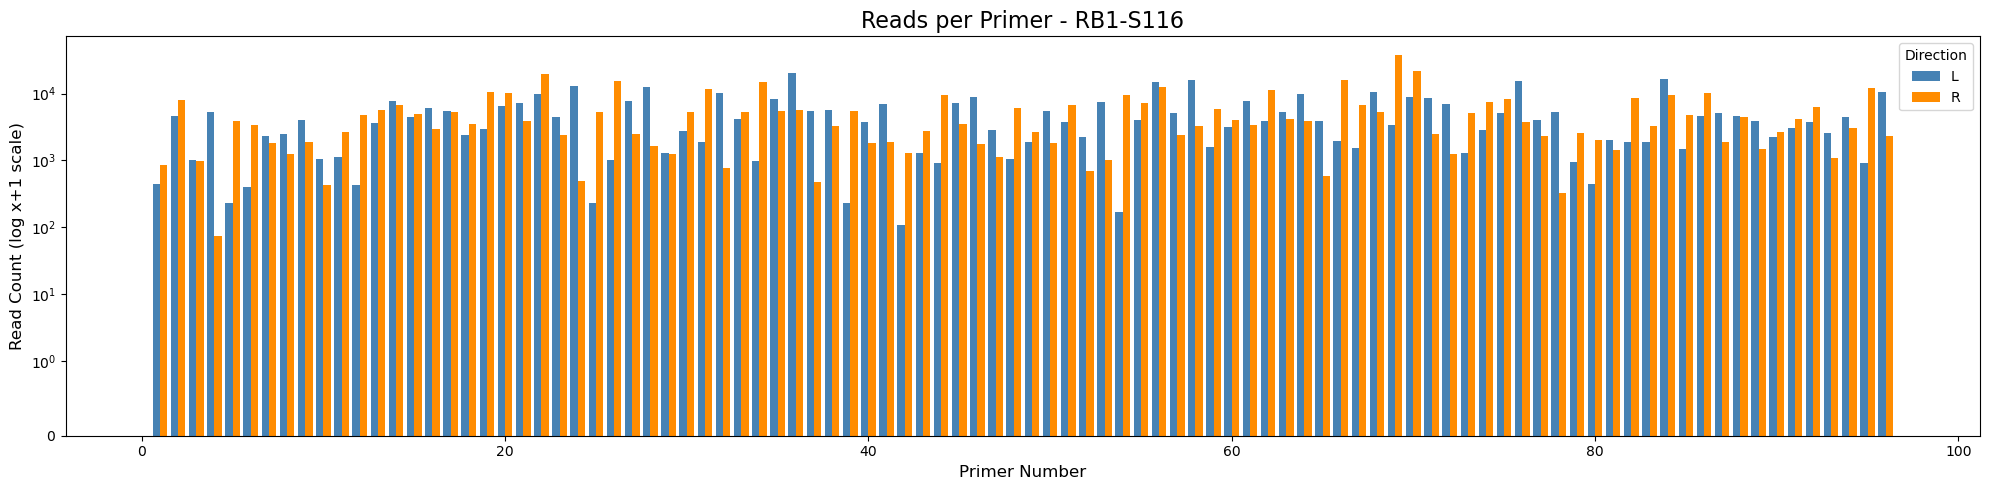

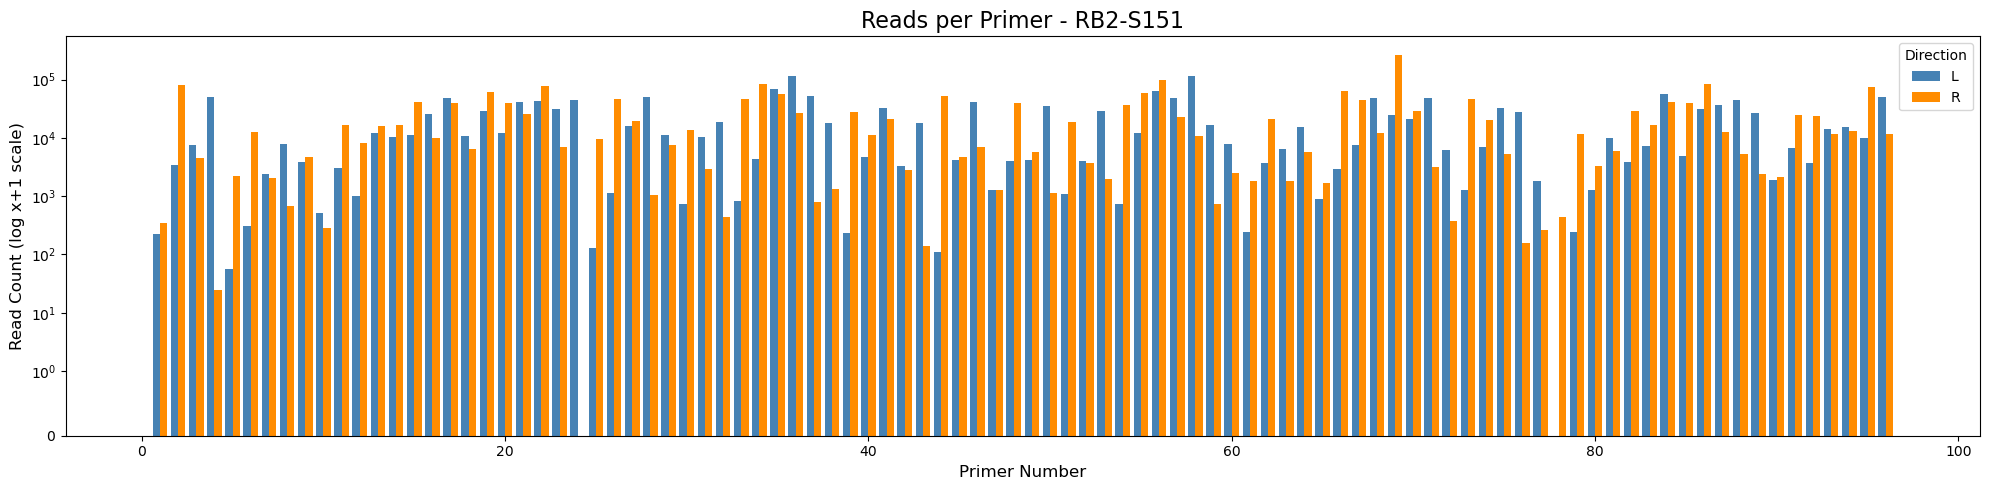

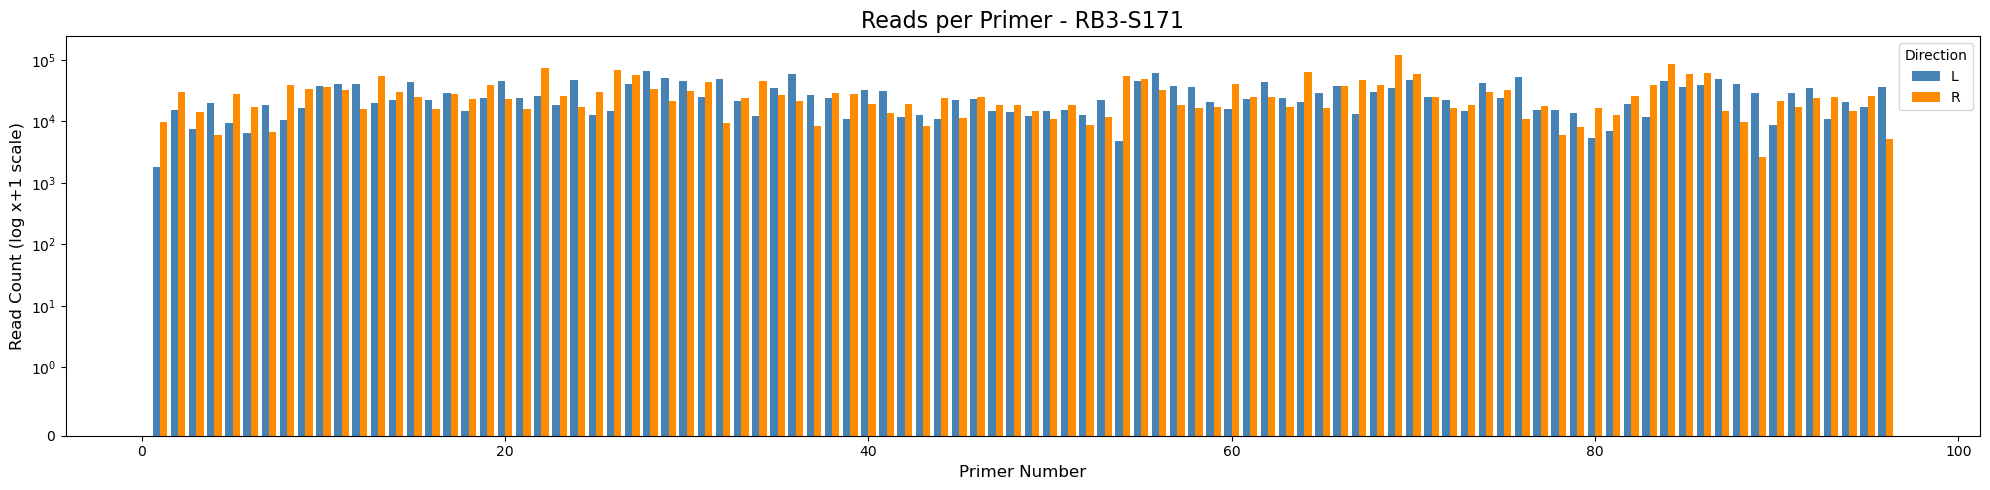

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re

primer_data = []

def get_primer_coverage(sample, target_out_dir=out_dir):
    import subprocess
    import os
    final_bam = os.path.join(target_out_dir, f"{sample}.trimmed.sorted.bam")
    if not os.path.exists(final_bam):
        return None
    primer_counts = {}
    bedcov_cmd = f"samtools bedcov {scheme} {final_bam}"
    res_bed = subprocess.run(bedcov_cmd, shell=True, capture_output=True, text=True, check=True)
    for line in res_bed.stdout.split('\n'):
        parts = line.strip().split('\t')
        if len(parts) >= 6:
            p_name = parts[3]
            try:
                depth = int(parts[-1])
                primer_counts[p_name] = depth
            except ValueError:
                pass
    return {"Sample": sample, "Primer_Counts": primer_counts}

# Build dataset directly from captured primer counts
for sample in samples:
    coverage_data = get_primer_coverage(sample)
    if coverage_data and "Primer_Counts" in coverage_data:
        for primer, count in coverage_data["Primer_Counts"].items():
            match = re.search(r'SARS-CoV-2_(\d+)_(LEFT|RIGHT)', primer)
            if match:
                num = int(match.group(1))
                direction = match.group(2)[0]
                locus = f"{num}{direction}"
                primer_data.append({
                    "Sample": sample,
                    "Primer_Num": num,
                    "Direction": direction,
                    "Locus": locus,
                    "Read Count": count
                })

df_primers = pd.DataFrame(primer_data)

if not df_primers.empty:
    # Group and sum the Read Counts by Sample and Locus to combine variants (e.g. 84_RIGHT_3 and 84_RIGHT_2)
    df_grouped = df_primers.groupby(["Sample", "Primer_Num", "Direction", "Locus"])["Read Count"].sum().reset_index()
    
    # Display Table showing the summed locus counts
    df_pivot_table = df_grouped.pivot(index="Locus", columns="Sample", values="Read Count").fillna(0)
    
    def locus_sort_key(locus):
        match = re.match(r'(\d+)([LR])', locus)
        if match:
            return (int(match.group(1)), match.group(2))
        return (0, locus)
        
    df_pivot_table['sort_key'] = [locus_sort_key(idx) for idx in df_pivot_table.index]
    df_pivot_table = df_pivot_table.sort_values('sort_key').drop('sort_key', axis=1)
    
    with pd.option_context('display.max_rows', None):
        display(df_pivot_table)
        
    # Draw grouped numeric Bar Charts
    for sample in samples:
        sample_data = df_grouped[df_grouped["Sample"] == sample]
        if sample_data.empty:
            continue
            
        df_sample_pivot = sample_data.pivot(index="Primer_Num", columns="Direction", values="Read Count").fillna(0)
        
        fig, ax = plt.subplots(figsize=(20, 5))
        
        if 'L' in df_sample_pivot.columns:
            ax.bar(df_sample_pivot.index - 0.2, df_sample_pivot['L'], width=0.4, color='steelblue', label='L')
        if 'R' in df_sample_pivot.columns:
            ax.bar(df_sample_pivot.index + 0.2, df_sample_pivot['R'], width=0.4, color='darkorange', label='R')
            
        ax.set_title(f"Reads per Primer - {sample}", fontsize=16)
        ax.set_xlabel("Primer Number", fontsize=12)
        ax.set_ylabel("Read Count (log x+1 scale)", fontsize=12)
        ax.set_yscale("symlog", linthresh=1)
        ax.legend(title="Direction")
        
        plt.tight_layout()
        plt.show()
else:
    print("No primer depth data found.")

## Consensus Sequence
Generate a consensus sequence for each sample using `samtools mpileup` and `ivar consensus`, then calculate the frequency of 'N's.

In [8]:

def generate_consensus(sample, target_out_dir=out_dir):
    print(f"Generating consensus for {sample}...")
    final_bam = os.path.join(target_out_dir, f"{sample}.trimmed.sorted.bam")
    consensus_prefix = os.path.join(target_out_dir, f"{sample}.consensus")
    fasta_out = consensus_prefix + ".fa"
    
    if not os.path.exists(final_bam):
        print(f"BAM file not found for {sample}")
        return None
        
    mpileup_cmd = f"samtools mpileup -aa -A -d 0 -B -Q 0 --reference {reference} {final_bam}"
    # Use -m 3 to set minimum coverage to 5 instead of default 10 to try to handle our low read samples
    # We will need to be extra careful to validate that any novel variants are indeed real.
    # With -m 3 I saw several obvious errors (eg. frame shift insertions)
    ivar_cmd = f"ivar consensus -p {consensus_prefix} -m 5 -n N"
    
    full_cmd = f"{mpileup_cmd} | {ivar_cmd}"
    subprocess.run(full_cmd, shell=True, check=True)
    
    if os.path.exists(fasta_out):
        with open(fasta_out, 'r') as f:
            lines = f.readlines()
            
        seq = "".join([line.strip() for line in lines if not line.startswith(">")])
        total_len = len(seq)
        n_count = seq.upper().count('N')
        coverage = ((total_len - n_count) / total_len) if total_len > 0 else 0
        
        return {
            "Sample": sample,
            "Total Length": total_len,
            "N Count": n_count,
            "Coverage": round(coverage, 4)
        }
    return None



In [9]:
cons_RB1_S116 = generate_consensus("RB1-S116")

Generating consensus for RB1-S116...
Minimum Quality: 20
Threshold: 0
Minimum depth: 5
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
[mpileup] Max depth set to maximum value (2147483647)


Reference length: 29903
Positions with 0 depth: 313
Positions with depth below 5: 411


In [10]:
cons_RB2_S151 = generate_consensus("RB2-S151")

Generating consensus for RB2-S151...
Minimum Quality: 20
Threshold: 0
Minimum depth: 5
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
[mpileup] Max depth set to maximum value (2147483647)


Reference length: 29903
Positions with 0 depth: 842
Positions with depth below 5: 1924


In [11]:
cons_RB3_S171 = generate_consensus("RB3-S171")

Generating consensus for RB3-S171...
Minimum Quality: 20
Threshold: 0
Minimum depth: 5
Minimum Insert Threshold: 0.8
Regions with depth less than minimum depth covered by: N


[mpileup] 1 samples in 1 input files
[mpileup] Max depth set to maximum value (2147483647)


Reference length: 29903
Positions with 0 depth: 3
Positions with depth below 5: 29


### Consensus Statistics

In [12]:
consensus_stats = [s for s in [cons_RB1_S116, cons_RB2_S151, cons_RB3_S171] if s]
df_consensus = pd.DataFrame(consensus_stats)
display(df_consensus)

,Sample,Total Length,N Count,Coverage
0,RB1-S116,29847,411,0.9862
1,RB2-S151,29847,1925,0.9355
2,RB3-S171,29800,29,0.9990


## Nextclade Analysis
Generate a Nextclade report for the 3 generated consensus sequences.

In [13]:
import subprocess
import pandas as pd
import os
from IPython.display import display, HTML

# Switch context into the primary output directory 
os.chdir(out_dir)

combined_fasta = os.path.join(out_dir, "all_consensus.fa")
with open(combined_fasta, "w") as outfile:
    for sample in samples:
        fasta_in = os.path.join(out_dir, f"{sample}.consensus.fa")
        if os.path.exists(fasta_in):
            with open(fasta_in, "r") as infile:
                lines = infile.readlines()
                outfile.write(f">{sample}\n")
                for line in lines:
                    if not line.startswith(">"):
                        outfile.write(line)

nextclade_out = os.path.join(out_dir, "nextclade_report.tsv")
nextclade_html = os.path.join(out_dir, "nextclade_report.html")
dataset_dir = os.path.join(out_dir, "sars-cov-2-dataset")

print("Running Nextclade on consensus sequences...")

try:
    if not os.path.exists(dataset_dir):
        subprocess.run(["nextclade", "dataset", "get", "--name", "sars-cov-2", "--output-dir", dataset_dir], check=True)
    subprocess.run(["nextclade", "run", "--input-dataset", dataset_dir, "--output-tsv", nextclade_out, combined_fasta], check=True)
except subprocess.CalledProcessError as e:
    print("Nextclade execution failed:", e)
except FileNotFoundError:
    print("Nextclade tool not found in PATH.")

if os.path.exists(nextclade_out):
    df_nc = pd.read_csv(nextclade_out, sep='\t')
    
    # Compute relative substitutions and deletions from Pango founder
    def count_muts(mut_str):
        if pd.isna(mut_str): return 0
        s = str(mut_str).strip()
        return len(s.split(',')) if s else 0
        
    df_nc["pango_substitutions"] = df_nc.get("privateNucMutations.totalPrivateSubstitutions", df_nc["totalSubstitutions"])
    
    if "founderMuts['Nextclade_pango'].deletions" in df_nc.columns:
        df_nc["pango_deletions"] = df_nc["totalDeletions"] - df_nc["founderMuts['Nextclade_pango'].deletions"].apply(count_muts)
    else:
        df_nc["pango_deletions"] = df_nc["totalDeletions"]
        
    df_nc["pango_insertions"] = df_nc["totalInsertions"] # Insertions are extremely rare as founder mutations
    
    cols_to_show = ["seqName", "clade", "Nextclade_pango", "pango_substitutions", "pango_deletions", "pango_insertions", "totalMissing", "qc.overallScore", "qc.overallStatus"]
    
    df_display = df_nc[[c for c in cols_to_show if c in df_nc.columns]].rename(columns={
        "pango_substitutions": "Pango Relative Substitutions",
        "pango_deletions": "Pango Relative Deletions",
        "pango_insertions": "Pango Relative Insertions"
    })
    display(df_display)




Running Nextclade on consensus sequences...


,seqName,clade,Nextclade_pango,Pango Relative Substitutions,Pango Relative Deletions,Pango Relative Insertions,totalMissing,qc.overallScore,qc.overallStatus
0,RB1-S116,24A,JN.1.43.1,2,68,12,411,0.169012,good
1,RB3-S171,25B,PQ.2.8.1,6,112,12,29,6.250000,good
2,RB2-S151,25B,PQ.24,6,68,12,1925,37.785065,mediocre


In [14]:
import textwrap
import os
import glob

def format_fasta_multiline(fasta_path, line_length=60):
    with open(fasta_path, 'r') as f:
        lines = f.readlines()
        
    if not lines: return
    
    header = lines[0].strip()
    seq = "".join(line.strip() for line in lines[1:])
    
    with open(fasta_path, 'w') as f:
        f.write(header + "\n")
        # Write sequence wrapped to line_length
        for chunk in textwrap.wrap(seq, line_length):
            f.write(chunk + "\n")

# Apply to all consensus sequences
if 'out_dir' in globals():
    consensus_files = glob.glob(os.path.join(out_dir, "*.consensus.fa"))
    for cf in consensus_files:
        format_fasta_multiline(cf)
        print(f"Reformatted {cf} to multi-line FASTA")
else:
    print("out_dir not defined - could not reformat FASTA files automatically.")


Reformatted /Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB2-S151.consensus.fa to multi-line FASTA
Reformatted /Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB1-S116.consensus.fa to multi-line FASTA
Reformatted /Users/rick/Lab/RespiCov-analyze/../Q11-MG1-SC2/alignments/RB3-S171.consensus.fa to multi-line FASTA
